# SmartCart Customer Segmentation
## Unsupervised ML for E-commerce Marketing Strategy

### Problem Statement
SmartCart is a growing e-commerce platform serving customers across 
multiple countries. Currently, the company uses generic marketing 
strategies for all customers — resulting in wasted budget, missed 
opportunities, and poor retention.

**Goal:** Use unsupervised machine learning to discover hidden 
customer segments from behavioral and demographic data, and 
translate those segments into actionable marketing strategies.

### Dataset
- 2,240 customer records with 22 attributes
- Covers demographics, purchase behaviour, and campaign response
- Source: Customer Personality Analysis (UCI / Kaggle)

### Approach
1. Data Cleaning & Missing Value Treatment
2. Feature Engineering
3. Outlier Detection & Removal
4. EDA & Correlation Analysis
5. Feature Encoding & Scaling
6. Dimensionality Reduction (PCA)
7. K-Means + Agglomerative Clustering
8. Cluster Profiling & Business Insights

### Key Result
Identified 4 distinct customer segments with specific income, 
spending, and behavioral patterns — enabling SmartCart to shift 
from generic to precision marketing.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Loading and Analysing our data

In [2]:
customer_data=pd.read_csv("smartcart_customers.csv")

In [3]:
customer_data.shape

(2240, 22)

In [4]:
customer_data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [5]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
customer_data.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [7]:
customer_data.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.009375,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.096391,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000


## 2. Handling missing value-->Income

In [8]:
import numpy as np
from sklearn.impute import SimpleImputer

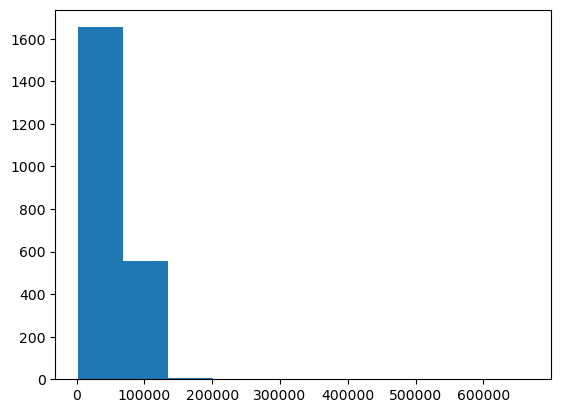

In [9]:
plt.hist(customer_data['Income'])
plt.show()

##### Income is right skewed (verified via histogram)
##### Using median to avoid mean being pulled by high income outliers

In [10]:
imputer=SimpleImputer(strategy="median")
customer_data["Income"]=imputer.fit_transform(customer_data[["Income"]])

In [11]:
#verifying
customer_data[["Income"]].isnull().sum()

Income    0
dtype: int64

## 3. Feature Engineering

#### Extracting "Age" column from "Year_Birth" column

In [12]:
customer_data["Age"]=2026-customer_data["Year_Birth"]

#### Extracting "Customer_Tenure_days" column from "Dt_Customer" column

In [13]:
#converting Dt_Customer to date-time format
customer_data["Dt_Customer"]=pd.to_datetime(customer_data["Dt_Customer"],dayfirst=True)

In [14]:
#customer tenure=most recent joing date of customer(reference date)-Dt_Customer
# we are taking this reference date rather than current date-time so that our output remain preserved whenever we run the code


reference_date=customer_data["Dt_Customer"].max()

customer_data["Customer_Tenure_Days"]=(reference_date-customer_data["Dt_Customer"]).dt.days

#### Extracting "Total_Spending" by adding all Mnt columns 

In [15]:
customer_data["Total_Spending"]=customer_data["MntWines"]+customer_data["MntFruits"]+customer_data["MntMeatProducts"]+customer_data["MntFishProducts"]+customer_data["MntSweetProducts"]+customer_data["MntGoldProds"]

#### Extracting Total_Children = Kidhome + Teenhome

In [16]:
customer_data["Total_Children"]=customer_data["Kidhome"]+customer_data["Teenhome"]

#### Extracting basic "Undergraduate","Graduate","Postgraduate" from Eduaction column

In [17]:
customer_data["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [18]:
customer_data["Education"]=customer_data["Education"].replace({
    "Basic":"Undergraduate", "2n Cycle":"Undergraduate",
    "Graduation":"Graduate", 
    "Master":"Postgraduate","PhD":"Postgraduate"
}    
)

#### Extracting Living_with_status(Partner,Alone) from different Marital_status values

In [19]:
customer_data["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [20]:
customer_data["Living_With"]=customer_data["Marital_Status"].replace({
    "Married":"Partner", "Together":"Partner",
    "Single":"Alone", "Divorced":"Alone","Widow":"Alone","Alone":"Alone",
    "Absurd":"Alone","YOLO":"Alone"
}    
)

In [21]:
customer_data["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

In [22]:
#verifying
customer_data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


###  Dropping  columns

In [23]:
data_cleaned=customer_data.drop(["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer","MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"],axis=1)

In [24]:
data_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


In [25]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Education             2240 non-null   object 
 1   Income                2240 non-null   float64
 2   Recency               2240 non-null   int64  
 3   NumDealsPurchases     2240 non-null   int64  
 4   NumWebPurchases       2240 non-null   int64  
 5   NumCatalogPurchases   2240 non-null   int64  
 6   NumStorePurchases     2240 non-null   int64  
 7   NumWebVisitsMonth     2240 non-null   int64  
 8   Complain              2240 non-null   int64  
 9   Response              2240 non-null   int64  
 10  Age                   2240 non-null   int64  
 11  Customer_Tenure_Days  2240 non-null   int64  
 12  Total_Spending        2240 non-null   int64  
 13  Total_Children        2240 non-null   int64  
 14  Living_With           2240 non-null   object 
dtypes: float64(1), int64(

## Outliers handling

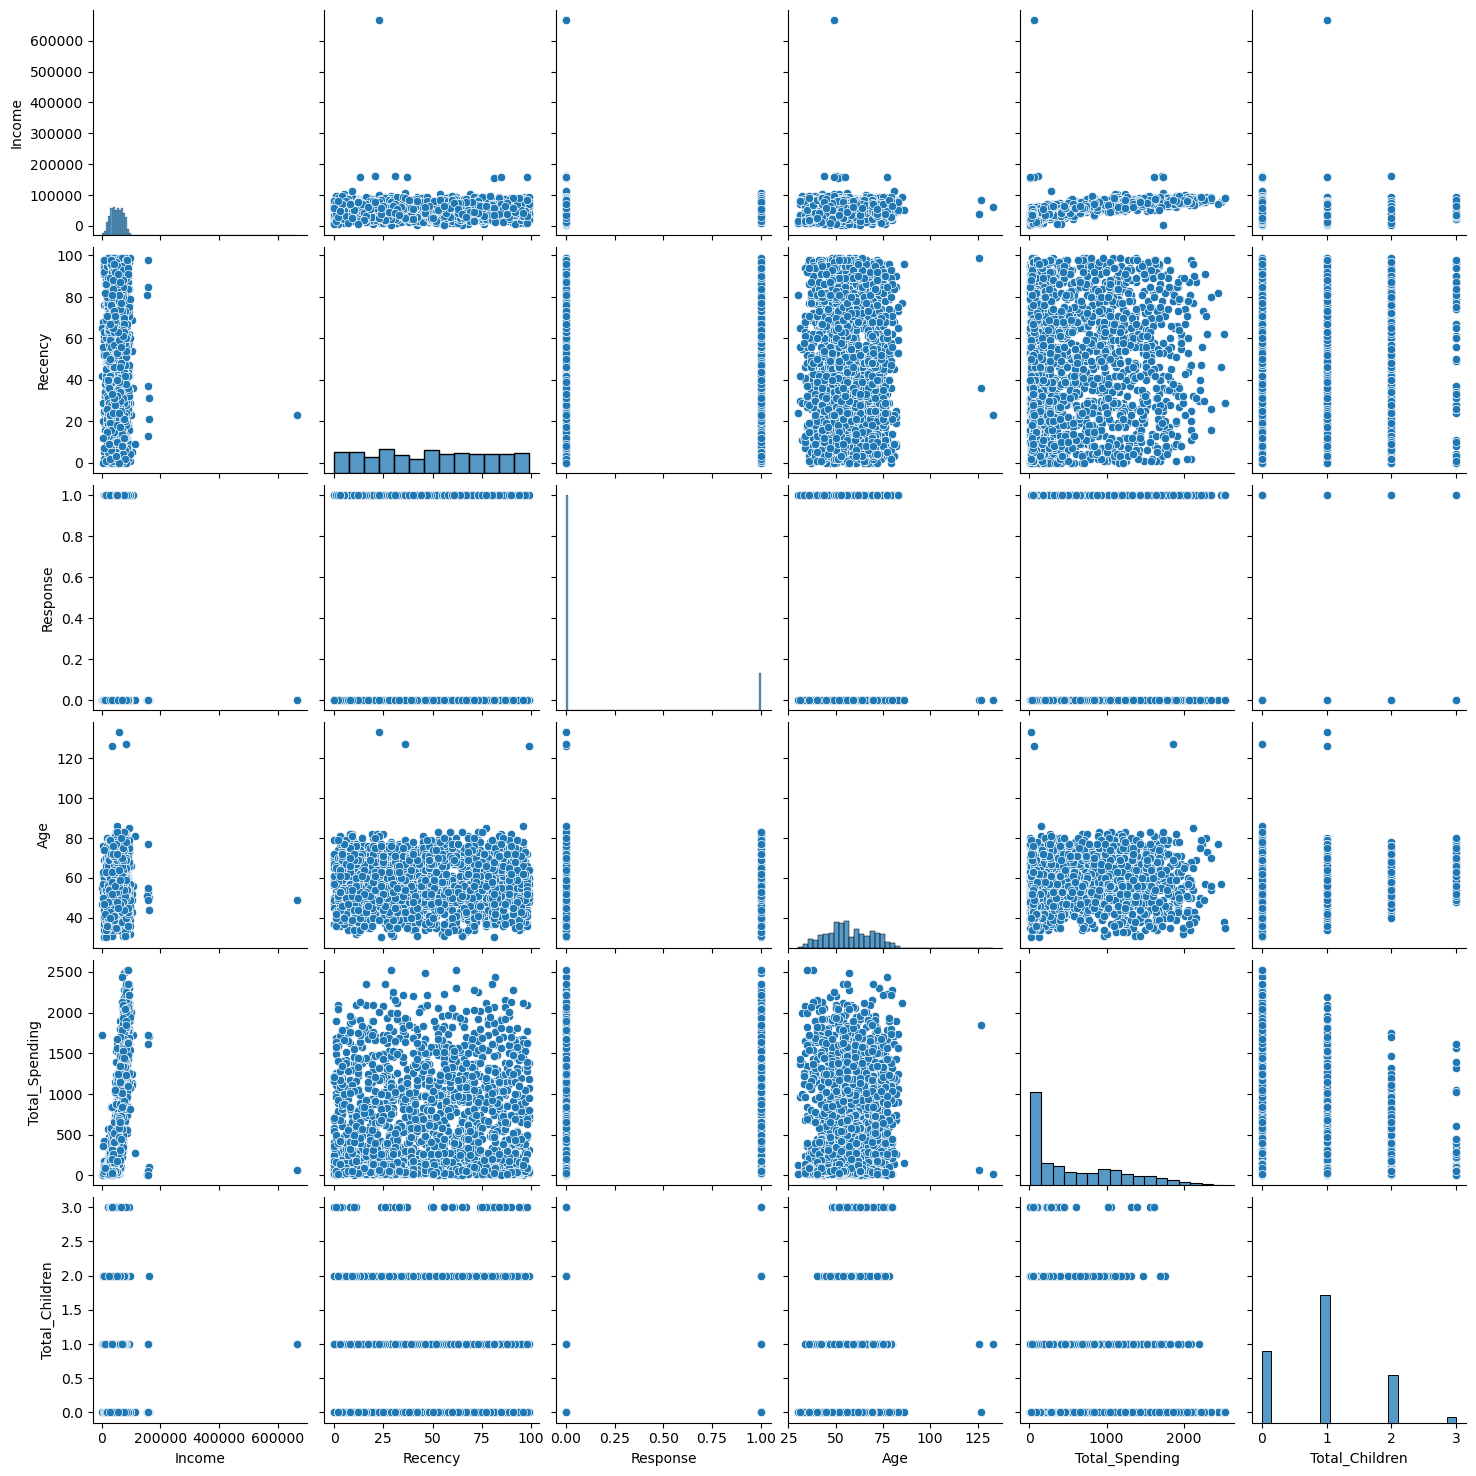

In [26]:
cols=["Income","Recency","Response","Age","Total_Spending","Total_Children"]

#relative plot of some feature-pair plot
sns.pairplot(data_cleaned[cols])

#### From the pairplots we can analyse the existence of few outliers-->An outlier with income greater than 600_000 and few outliers with age>90-100.
#### Removing the outliers and verifying
   

In [27]:
print("data with outliers", len(data_cleaned))

data with outliers 2240


In [28]:
data_cleaned=data_cleaned[(data_cleaned["Age"]<90)]
data_cleaned=data_cleaned[(data_cleaned["Income"]<600_000)]

In [29]:
print("data without outliers", len(data_cleaned))

data without outliers 2236


## EDA

<Axes: xlabel='Income', ylabel='Count'>

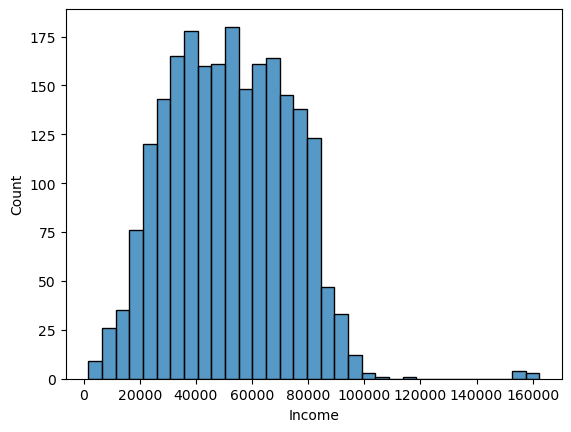

In [30]:
sns.histplot(
    data=data_cleaned,
    x="Income"
)

<Axes: xlabel='Age', ylabel='Count'>

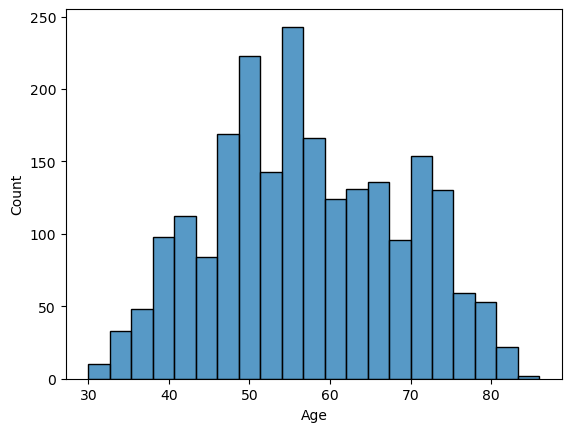

In [31]:
sns.histplot(
    data=data_cleaned,
    x="Age"
)

<Axes: xlabel='Total_Spending', ylabel='Count'>

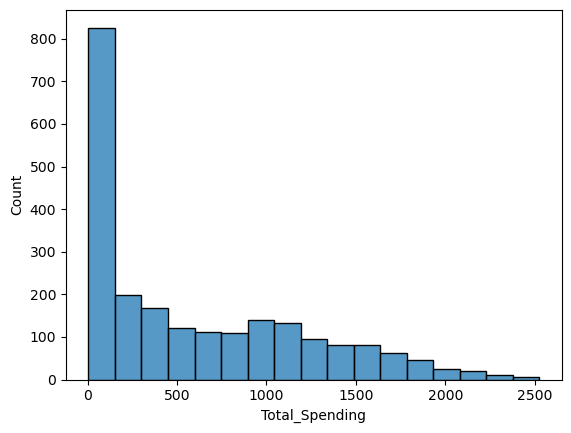

In [32]:
sns.histplot(
    data=data_cleaned,
    x="Total_Spending"
)

## Heatmap

In [33]:
corr=data_cleaned.corr(numeric_only=True)

<Axes: >

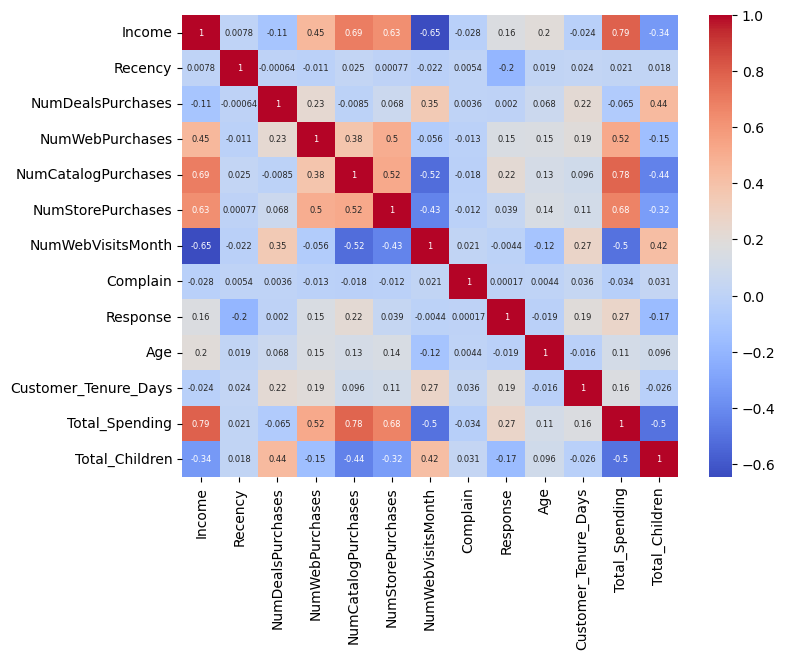

In [34]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
    
)

#### From the heatmap we can see that Income and Total_Spending is positively correlated with highest value of 0.79

### ENCODING

In [35]:
from sklearn.preprocessing import OneHotEncoder

In [36]:
ohe=OneHotEncoder()
cat_cols=["Education","Living_With"]
enc_cols=ohe.fit_transform(data_cleaned[cat_cols])

In [37]:
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=data_cleaned.index)

In [38]:
df_encoded=pd.concat([data_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [39]:
df_encoded.shape

(2236, 18)

In [40]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


### Scaling

In [41]:
from sklearn.preprocessing import StandardScaler

In [42]:
X=df_encoded

In [43]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

## Visualize

### 2D

In [44]:
from sklearn.decomposition import PCA

In [45]:
pca=PCA(
    n_components=2
)

X_pca=pca.fit_transform(X_scaled)

#### PLOT

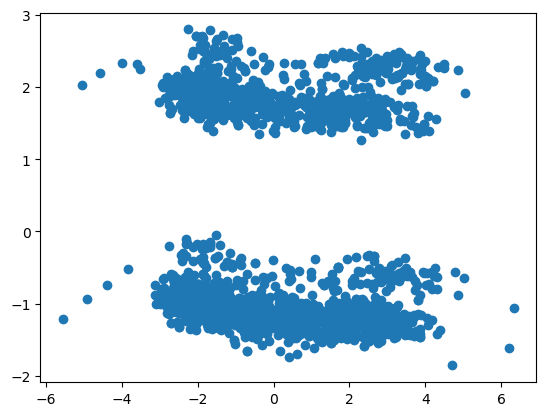

In [46]:
plt.scatter(X_pca[:,0],X_pca[:,1])

In [47]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454])

### 3D

In [48]:
pca=PCA(
    n_components=3
)

X_pca=pca.fit_transform(X_scaled)

#### PLOT

Text(0.5, 0.92, ' 3D PCA Projection of Customer Data')

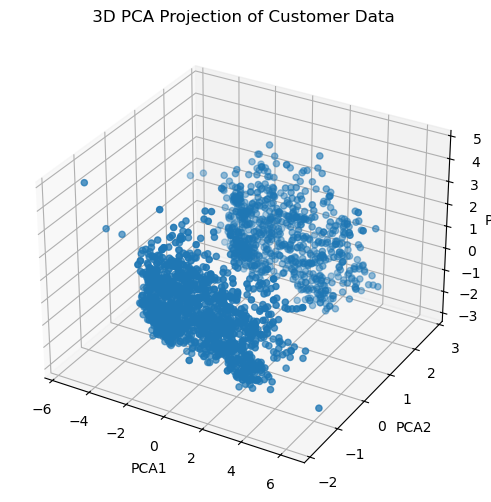

In [49]:
fig=plt.figure(figsize=(8,6))

ax=fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title(" 3D PCA Projection of Customer Data")



In [50]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

## Analyze K value

### 1.ELBOW METHOD

In [51]:
import warnings
warnings.filterwarnings("ignore")

In [52]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

In [53]:
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)


In [54]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

print("optimal k=",knee.elbow)

optimal k= 4


Text(0, 0.5, 'WCSS')

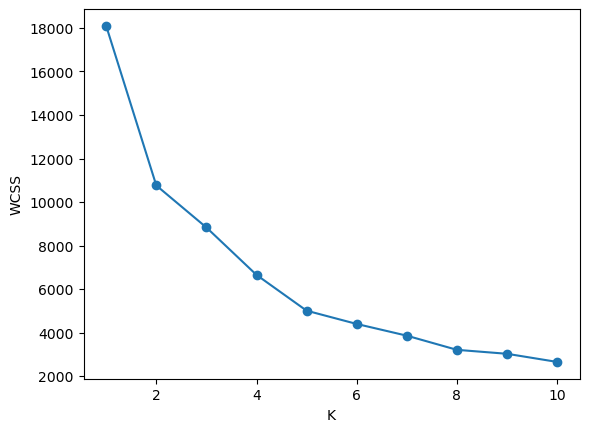

In [55]:
plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("K")
plt.ylabel("WCSS")

### 2.Silhouette Score

In [56]:
from sklearn.metrics import silhouette_score
scores=[]

for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(X_pca)
    score=silhouette_score(X_pca,labels)
    scores.append(score)


#### Plot

Text(0, 0.5, 'Silhouette Score')

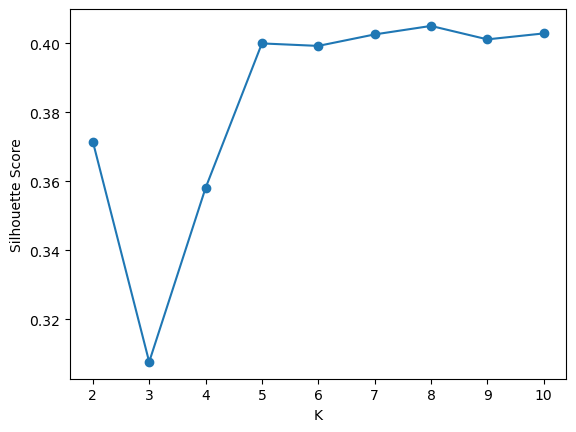

In [57]:
plt.plot(range(2,11),scores,marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette Score")

#### Combined plot of Elbow method and Silhouette Score

Text(0, 0.5, 'Silhouette score')

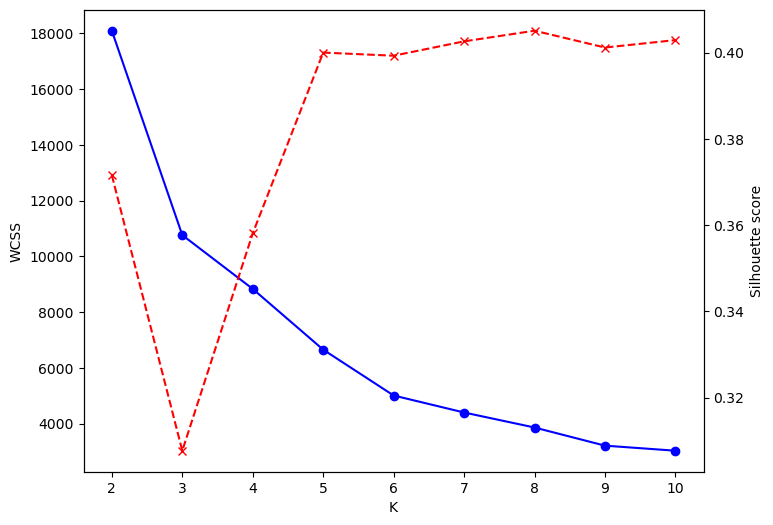

In [58]:
k_range=range(2,11)

fig,ax1=plt.subplots(figsize=(8,6))

ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")


ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x",color="red",linestyle="--")
ax2.set_xlabel("K")
ax2.set_ylabel("Silhouette score")

## CLUSTERING

### K Means

In [59]:
kmeans=KMeans(n_clusters=4,random_state=42)
labels_kmeans=kmeans.fit_predict(X_pca)

Text(0.5, 0.92, 'K-Means Clustering — 4 Customer Segments (3D PCA)')

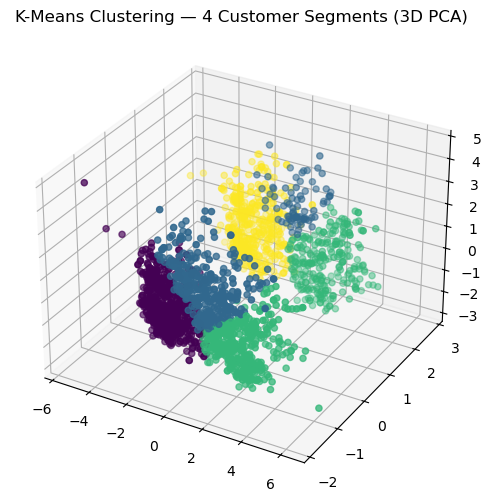

In [60]:
fig=plt.figure(figsize=(8,6))

ax=fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_kmeans)

ax.set_title("K-Means Clustering — 4 Customer Segments (3D PCA)")

### Agglomerative Clustering

In [61]:
from sklearn.cluster import AgglomerativeClustering

In [62]:
agg_clf=AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg=agg_clf.fit_predict(X_pca)

Text(0.5, 0.92, 'Agglomerative Clustering — 4 Customer Segments (3D PCA)')

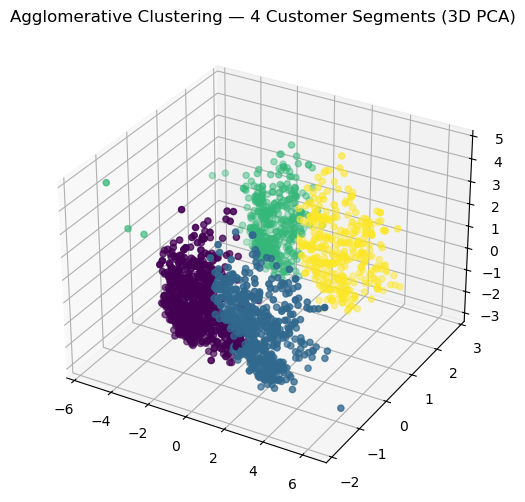

In [63]:
fig=plt.figure(figsize=(8,6))

ax=fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)

ax.set_title("Agglomerative Clustering — 4 Customer Segments (3D PCA)")

#### Now here we see agglomerative clustering is giving better seperated 4 cluster rather than k means.

## Characterization of Clusters

In [64]:
X["cluster"]=labels_agg

In [65]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

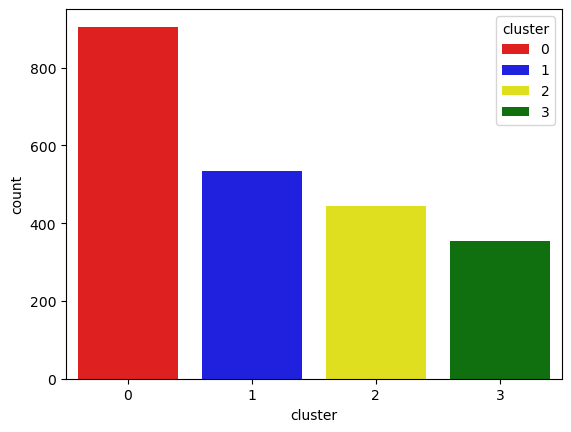

In [66]:
pal=["red","blue","yellow","green"]

sns.countplot(x=X["cluster"],palette=pal,hue=X["cluster"])

#### Income & spending patterns

<Axes: xlabel='Total_Spending', ylabel='Income'>

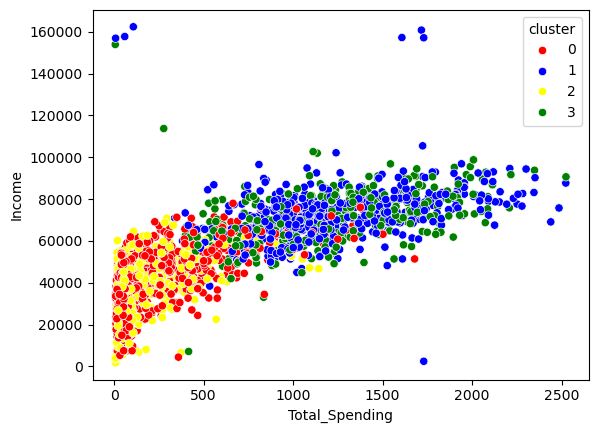

In [67]:
sns.scatterplot(x=data_cleaned["Total_Spending"],y=data_cleaned["Income"],hue=X["cluster"],palette=pal)

## Cluster Summary

In [68]:
cluster_summary=X.groupby("cluster").mean()

In [69]:
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         

## Radar Chart — Cluster Comparison
Normalized comparison of key behavioral and demographic 
features across all 4 customer segments.

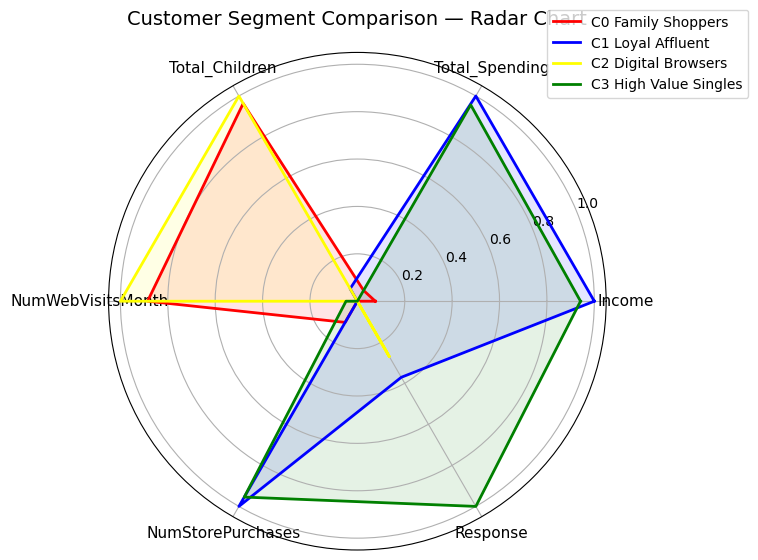

In [70]:
# Features to compare across clusters
categories = ['Income', 'Total_Spending', 'Total_Children', 
              'NumWebVisitsMonth', 'NumStorePurchases', 'Response']

# Get cluster means for these features
radar_data = X.groupby('cluster')[categories].mean()

# Normalize to 0-1 scale so all features are comparable
radar_normalized = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

# Number of variables
N = len(categories)

# Angle for each feature
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close the circle

# Plot setup
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors = ['red', 'blue', 'yellow', 'green']
cluster_names = ['C0 Family Shoppers', 'C1 Loyal Affluent', 
                 'C2 Digital Browsers', 'C3 High Value Singles']

for i in range(4):
    values = radar_normalized.iloc[i].tolist()
    values += values[:1]  # close the circle
    
    ax.plot(angles, values, linewidth=2, 
            linestyle='solid', label=cluster_names[i], color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

# Add feature labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)

ax.set_title('Customer Segment Comparison — Radar Chart', 
             size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

## Cluster Heatmap — Feature Averages

The heatmap below shows average values of key features per cluster.
Darker red indicates higher values, darker blue indicates lower values.

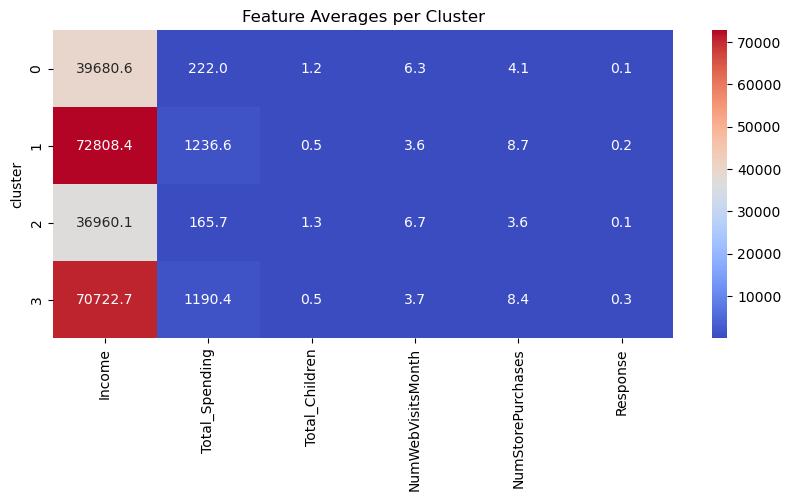

In [71]:
# Key observations:
# - Clusters 1 and 3 dominate on Income and Spending — high value segments
# - Clusters 0 and 2 show highest Children and Web Visits — family/browser behavior  
# - Cluster 3 has highest Response rate (0.3) — best ROI for marketing spend
# - Cluster 2 lowest spending (165.7) despite high web visits — window shopper pattern


plt.figure(figsize=(10,4))
sns.heatmap(
    cluster_summary[['Income','Total_Spending',
    'Total_Children','NumWebVisitsMonth',
    'NumStorePurchases','Response']],
    annot=True, fmt='.1f', cmap='coolwarm'
)
plt.title('Feature Averages per Cluster')
plt.show()

## Cluster Profiling & Business Insights

The clustering reveals 4 distinct customer segments based on 
income, spending behavior, family structure, and marketing 
responsiveness. Each segment requires a fundamentally different 
business strategy.

## Cluster 0 — "Family Shoppers" (Price Sensitive)

### Who Are They?
Low-to-moderate income families who prioritize value over quality.
They have the most children at home and live with a partner.
They browse the web frequently but convert poorly — actively 
searching for deals before committing to any purchase.

### Key Numbers
| Metric | Value |
|--------|-------|
| Average Income | $39,680 |
| Average Total Spending | $222 |
| Avg Children at Home | 1.24 (highest) |
| Living Situation | 100% with Partner |
| Campaign Response Rate | 7.6% (lowest) |
| Top Channel | Web browsing |

### Business Strategy
- Target with discount coupons, family bundle offers, seasonal promotions
- Web-based campaigns are the only effective channel for this group
- Avoid premium product pushes — price sensitivity is very high
- Flash sales and limited-time deals drive conversions here

### Why This Matters
High digital presence makes them reachable cheaply at scale.
Low spend per customer but large segment size offers volume potential
with the right discount-first strategy.

## Cluster 1 — "Loyal Affluent Families"

### Who Are They?
High income customers living with a partner with fewer children.
They strongly prefer physical shopping — highest store and catalog 
purchases of all segments. Moderate campaign response suggests 
brand loyalty over deal-seeking behavior.

### Key Numbers
| Metric | Value |
|--------|-------|
| Average Income | $72,808 (highest) |
| Average Total Spending | $1,236 |
| Avg Children at Home | 0.51 |
| Living Situation | 100% with Partner |
| Campaign Response Rate | 16.7% |
| Top Channel | Store + Catalog |

### Business Strategy
- Introduce loyalty reward programs and membership benefits
- Focus on in-store experience and personalized recommendations
- Catalog-based promotions work well — they shop offline
- Do NOT rely on heavy discounts — they buy based on preference

### Why This Matters
Second highest spenders with strong retention potential.
High Lifetime Value (LTV) segment — loyalty investment here
pays back over years, not just one campaign.

## Cluster 2 — "Digital Browsers" (Budget Singles)

### Who Are They?
Lowest income segment living alone with children.
They visit the website the most of any segment but spend the least
— classic window shoppers. When they do convert, heavy discounts
are the trigger.

### Key Numbers
| Metric | Value |
|--------|-------|
| Average Income | $36,960 (lowest) |
| Average Total Spending | $165 (lowest) |
| Avg Children at Home | 1.27 (highest) |
| Living Situation | 99% Alone |
| Campaign Response Rate | 14.2% |
| Top Channel | Web (highest visits of all segments) |

### Business Strategy
- Target with heavy discount campaigns and flash sales
- Web and app-based promotions are the only effective channel
- Personalized budget-friendly product recommendations
- Focus on converting their high web activity into actual purchases

### Why This Matters
High digital presence makes them easy and cheap to reach.
Discount-driven conversion is achievable at scale despite low AOV.

## Cluster 3 — "High Value Singles"  Best ROI Segment

### Who Are They?
High income individuals living alone with very few children.
They are the most responsive to marketing campaigns by a wide 
margin — nearly 1 in 3 respond. They spend significantly across 
both store and catalog channels and represent the highest revenue 
potential per customer of all segments.

### Key Numbers
| Metric | Value |
|--------|-------|
| Average Income | $70,722 |
| Average Total Spending | $1,190 |
| Avg Children at Home | 0.46 (lowest) |
| Living Situation | 100% Alone |
| Campaign Response Rate | 32%  (3x higher than Cluster 0) |
| Top Channel | Store + Catalog |

### Business Strategy
- Highest priority segment for premium service offerings
- Personalized outreach yields highest ROI — 1 in 3 customers respond
- Offer exclusive memberships, early product access, concierge-style service
- Upsell premium categories — wines, meats, gold products
- Retention investment here has the single highest payoff

### Why This Matters
Best combination of high income + high spending + high campaign 
responsiveness. Every marketing dollar spent on this segment 
returns the most revenue. Primary target for all premium initiatives.

## Overall Business Conclusion

| Cluster | Name | Avg Income | Avg Spending | Response Rate | Priority |
|---------|------|-----------|--------------|---------------|----------|
| C0 | Family Shoppers | $39,680 | $222 | 7.6% | Discount campaigns |
| C1 | Loyal Affluent Families | $72,808 | $1,236 | 16.7% | Loyalty programs |
| C2 | Digital Browsers | $36,960 | $165 | 14.2% | Web flash sales |
| C3 | High Value Singles  | $70,722 | $1,190 | 32.0% | Premium services |

### Key Strategic Insight
Clusters 1 and 3 share nearly identical income and spending levels
but differ entirely in household structure — C1 lives with a partner,
C3 lives alone. This means the same premium product can be marketed
to both segments, but messaging must differ:

- **C1 messaging** → Family experiences, couple-oriented value, 
  shared lifestyle upgrades
- **C3 messaging** → Personal indulgence, individual lifestyle, 
  exclusive self-rewards

Same budget. Same product. Completely different angle. 
This is where data-driven marketing creates real business impact.

### Final Recommendation
SmartCart should allocate marketing budget as follows:
1. **Cluster 3** — Premium campaigns, highest spend per customer, 
   best response rate. Maximum ROI.
2. **Cluster 1** — Loyalty retention programs. High LTV, 
   worth protecting long term.
3. **Cluster 0 & 2** — Discount-led digital campaigns. 
   Low cost to reach, volume-driven strategy.